# Hackathon AI & ML - M1 ISA - Université de Tours
**Objectif** : Prédire le statut vital des patients en 2019 (classification binaire)  
**Métrique** : F1-score  
**Données** : 59 049 patients, 1 525 variables (questionnaire, examen, labo, démo)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
print('Librairies chargées OK')

Librairies chargées OK


## 1. Chargement des données

In [2]:
print('Chargement des données...')
data = pd.read_csv(DATA_DIR / 'data.csv')
labels = pd.read_csv(DATA_DIR / 'ground_truth_train.csv')
test_idx = pd.read_csv(DATA_DIR / 'test_indexes.csv', header=None, names=['SEQN'])
metadata = pd.read_csv(DATA_DIR / 'features_metadata.csv')

print(f'data.csv        : {data.shape}')
print(f'ground_truth    : {labels.shape}')
print(f'test_indexes    : {test_idx.shape}')
print(f'features_meta   : {metadata.shape}')

Chargement des données...
data.csv        : (59064, 1540)
ground_truth    : (54064, 2)
test_indexes    : (5000, 1)
features_meta   : (1539, 5)


## 2. Exploration rapide (EDA)

Distribution de MORTSTAT_2019 (train) :
MORTSTAT_2019
0    45589
1     8475
Name: count, dtype: int64

Taux de mortalité : 15.68%


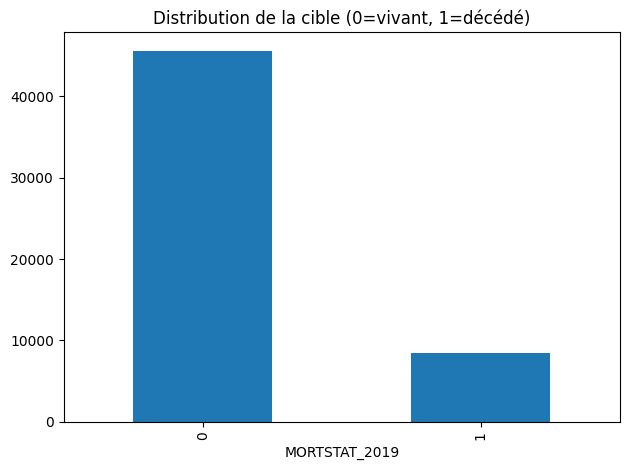

In [3]:
# Distribution de la cible
print('Distribution de MORTSTAT_2019 (train) :')
print(labels['MORTSTAT_2019'].value_counts())
print(f'\nTaux de mortalité : {labels["MORTSTAT_2019"].mean():.2%}')

labels['MORTSTAT_2019'].value_counts().plot(kind='bar', title='Distribution de la cible (0=vivant, 1=décédé)')
plt.tight_layout()
plt.show()

Colonnes avec >90% manquant : 679
Colonnes avec >50% manquant : 1357
Colonnes sans manquant      : 25


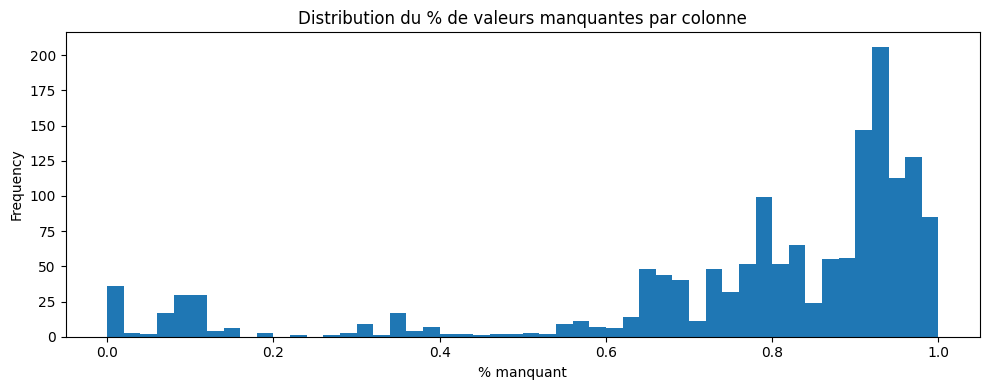

In [4]:
# Valeurs manquantes
missing_pct = data.isnull().mean().sort_values(ascending=False)
print(f'Colonnes avec >90% manquant : {(missing_pct > 0.9).sum()}')
print(f'Colonnes avec >50% manquant : {(missing_pct > 0.5).sum()}')
print(f'Colonnes sans manquant      : {(missing_pct == 0).sum()}')

plt.figure(figsize=(10, 4))
missing_pct.plot(kind='hist', bins=50, title='Distribution du % de valeurs manquantes par colonne')
plt.xlabel('% manquant')
plt.tight_layout()
plt.show()

In [5]:
# Catégories de variables (metadata)
print('Composantes des variables :')
print(metadata['Component'].value_counts())

print('\nFonctions (top 10) :')
# La colonne function contient des listes en string
print(metadata['function'].value_counts().head(10))

Composantes des variables :
Component
Laboratory                    845
Examination                   431
Questionnaire                 255
Demographics                    7
Examination##Questionnaire      1
Name: count, dtype: int64

Fonctions (top 10) :
function
[]                               636
['Vitalité']                     249
['Mobilité']                     176
['Sensoriel']                    116
['Mobilité', 'Vitalité']          78
['Vitalité', 'Psychologique']     13
['Cognition']                     11
['Cognition', 'Vitalité']          9
['Psychologique']                  4
['Vitalité', 'Sensoriel']          3
Name: count, dtype: int64


## 3. Préparation des données

In [6]:
# Séparation train / test
test_seqn = set(test_idx['SEQN'].values)
train_seqn = set(labels['SEQN'].values) - test_seqn

# Données d'entraînement
train_data = data[data['SEQN'].isin(train_seqn)].copy()
train_labels = labels[labels['SEQN'].isin(train_seqn)].copy()

# Données de test
test_data = data[data['SEQN'].isin(test_seqn)].copy()

print(f'Train : {train_data.shape}, Test : {test_data.shape}')

# Fusion train
train_df = train_data.merge(train_labels, on='SEQN')
print(f'Train mergé : {train_df.shape}')

Train : (54064, 1540), Test : (5000, 1540)
Train mergé : (54064, 1541)


In [ ]:
# Suppression des colonnes trop vides (> 80% manquant)
MISSING_THRESHOLD = 0.50
missing_ratio = train_df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
# Garder SEQN et la cible
cols_to_drop = [c for c in cols_to_drop if c not in ['SEQN', 'MORTSTAT_2019']]

print(f'Colonnes supprimées (>{MISSING_THRESHOLD*100:.0f}% manquant) : {len(cols_to_drop)}')

train_clean = train_df.drop(columns=cols_to_drop)
test_clean = test_data.drop(columns=[c for c in cols_to_drop if c in test_data.columns])

print(f'Train après nettoyage : {train_clean.shape}')

Colonnes supprimées (>20% manquant) : 1410
Train après nettoyage : (54064, 131)


In [8]:
# Features et cible
feature_cols = [c for c in train_clean.columns if c not in ['SEQN', 'MORTSTAT_2019']]

X = train_clean[feature_cols]
y = train_clean['MORTSTAT_2019']
X_test = test_clean[feature_cols]
test_seqn_ordered = test_clean['SEQN']

print(f'Features : {X.shape[1]}')
print(f'Exemples train : {X.shape[0]}')
print(f'Exemples test  : {X_test.shape[0]}')

Features : 129
Exemples train : 54064
Exemples test  : 5000


## 4. Modèle baseline - LightGBM

In [9]:
# Validation croisée stratifiée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
}

f1_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)])
    
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    f1_scores.append(f1)
    models.append(model)
    print(f'Fold {fold+1} - F1: {f1:.4f}')

print(f'\nF1 moyen CV : {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})')

Fold 1 - F1: 0.6535
Fold 2 - F1: 0.6587
Fold 3 - F1: 0.6608
Fold 4 - F1: 0.6562
Fold 5 - F1: 0.6378

F1 moyen CV : 0.6534 (+/- 0.0082)


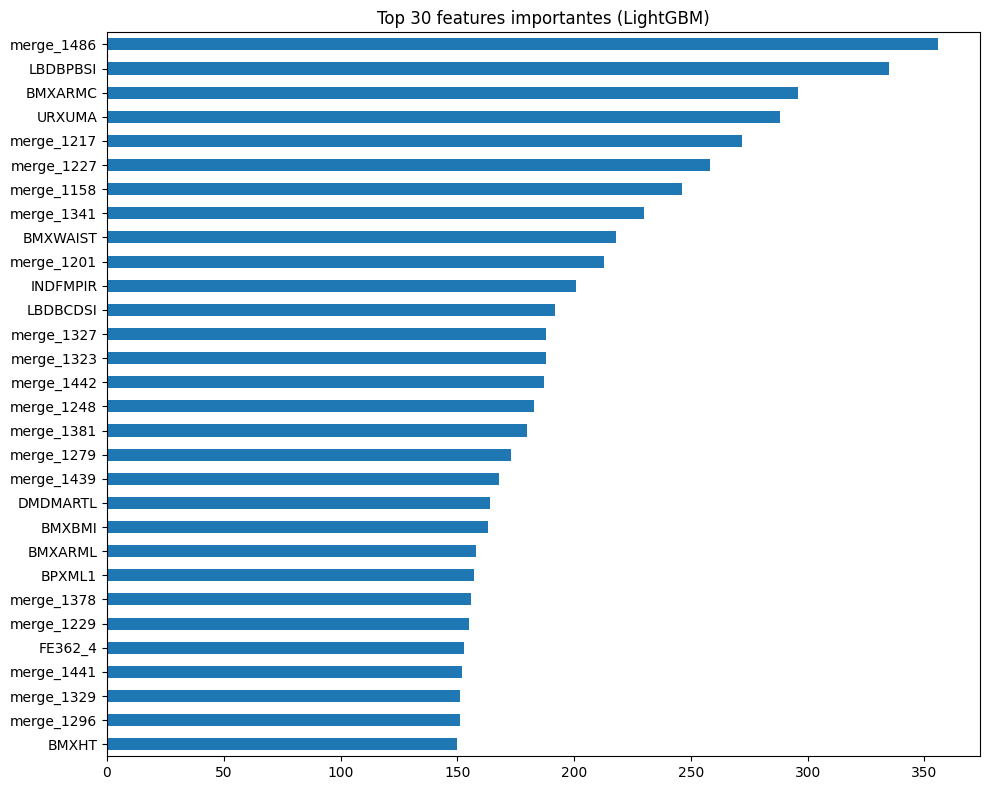

In [10]:
# Importance des features (meilleur modèle)
best_model = models[np.argmax(f1_scores)]
fi = pd.Series(best_model.feature_importances_, index=feature_cols)
fi_top = fi.nlargest(30)

plt.figure(figsize=(10, 8))
fi_top.sort_values().plot(kind='barh')
plt.title('Top 30 features importantes (LightGBM)')
plt.tight_layout()
plt.show()

## 5. Prédictions et soumission

In [ ]:
# Entraîner le meilleur modèle sur toutes les données train
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y, callbacks=[lgb.log_evaluation(period=-1)])

# Prédictions sur le test
y_pred_test = final_model.predict(X_test)

print(f'Prédictions test : {len(y_pred_test)}')
print(f'Répartition : {pd.Series(y_pred_test).value_counts().to_dict()}')

In [ ]:
# Création du fichier de soumission
# Format : [idgroupe]_[idsoumission].csv
# 2 colonnes (SEQN, prediction), triées par SEQN croissant, sans header

GROUP_ID = 'G1'   # <-- CHANGER selon votre groupe
SUBMISSION_ID = '1'  # <-- incrémenter à chaque soumission

submission = pd.DataFrame({
    'SEQN': test_seqn_ordered.values,
    'prediction': y_pred_test
}).sort_values('SEQN')

filename = f'{GROUP_ID}_{SUBMISSION_ID}.csv'
submission.to_csv(filename, index=False, header=False)

print(f'Fichier sauvegardé : {filename}')
print(f'Lignes : {len(submission)} (attendu : 5000)')
print(submission.head())

Fichier sauvegardé : G1_1.csv
Lignes : 5000 (attendu : 5000)
   SEQN  prediction
0    33           0
1    34           0
2    58           0
3   101           0
4   127           0


## 6. Pistes d'amélioration

- **Feature engineering** : variables démographiques (âge estimé, sexe RIAGENDR), BMI, etc.
- **Gestion des NaN** : imputation médiane, KNN imputer, ou modèles tolérant les NaN (LightGBM gère nativement)
- **Class imbalance** : `class_weight='balanced'`, SMOTE, ajustement du seuil de décision
- **Sélection de features** : filtrage par corrélation, importance, SHAP
- **Hyperparameter tuning** : Optuna, GridSearch
- **Stacking** : combiner LightGBM + XGBoost + Random Forest
- **Analyse clinique** : utiliser `features_metadata.csv` pour identifier les variables cliniquement pertinentes